In [1]:
# Load libraries
import os
import argparse

from pathlib import Path

from utils.data_loader import make_data_grid
from utils.train_tune_val import run_experiment

In [2]:
def main():
    # Parse command-line arguments
    parser = argparse.ArgumentParser()
    parser.add_argument("--case_id", type=int, default=None, help="0: QBF/M, 1: JF/M, etc.")
    parser.add_argument("--model_name", type=str, default="SVC", choices=["SVC", "DT", "RF", "GB", "XGB"])
    parser.add_argument("--n_repeats", type=int, default=2)
    parser.add_argument("--outer_splits", type=int, default=5)
    parser.add_argument("--inner_splits", type=int, default=5)
    parser.add_argument("--n_iter", type=int, default=10)
    parser.add_argument("--outer_verbose", type=int, default=20)
    parser.add_argument("--inner_verbose", type=int, default=1)
    parser.add_argument("--outer_n_jobs", type=int, default=-1)
    parser.add_argument("--inner_n_jobs", type=int, default=1)
    args = parser.parse_args(args=["--case_id", "0", "--model_name", "DT"])
    
    # Get and set data configuration
    cnfgs = make_data_grid()
    if args.case_id is not None:
        case_id = args.case_id
    else:
        case_id = int(os.environ.get("SLURM_ARRAY_TASK_ID", "0"))
    cnfg = cnfgs[case_id]

    # Set base directory for results
    base_dir = Path("../Results_Tests")
    out_dir = base_dir / args.model_name / f"sex={cnfg['sexes_key']}" / f"task={cnfg['tasks_key']}"

    cnfg.update({
        "model_name": args.model_name,
        "out_dir": out_dir,
        "n_repeats": args.n_repeats,
        "outer_splits": args.outer_splits,
        "inner_splits": args.inner_splits,
        "n_iter": args.n_iter,
        "outer_verbose": args.outer_verbose,
        "inner_verbose": args.inner_verbose,
        "outer_n_jobs": args.outer_n_jobs,
        "inner_n_jobs": args.inner_n_jobs,
    })

    # Run the experiment with nested cross-validation
    print(
        f"\n*** Running {cnfg['outer_splits']} outer folds and {cnfg['n_repeats']} repeats "
        f"for {args.model_name} | sex={cnfg['sexes_key']} | task={cnfg['tasks_key']} ***\n"
    )
    run_experiment(cnfg)


*** Running 5 outer folds and 2 repeats for DT | sex=Male | task=QBF ***



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 192 concurrent workers.


[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
[CV] START .....................................................................
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:   14.9s remaining:   59.5s
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:   14.9s remaining:   34.7s
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:   14.9s remaining:   22.3s
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:   14.9s remaining:   14.9s
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:   14.9s remaining:   10.0s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:   14.9s remaining:    6.4s
[Parallel(n_jobs=-1)]: Done   8 out of  10 | elapsed:   14.9s remaining:    3.7s


[CV] END  average_precision: (test=0.342) balanced_accuracy: (test=0.429) f1_score: (test=0.309) roc_auc: (test=0.433) total time=  11.6s


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   15.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   15.4s finished


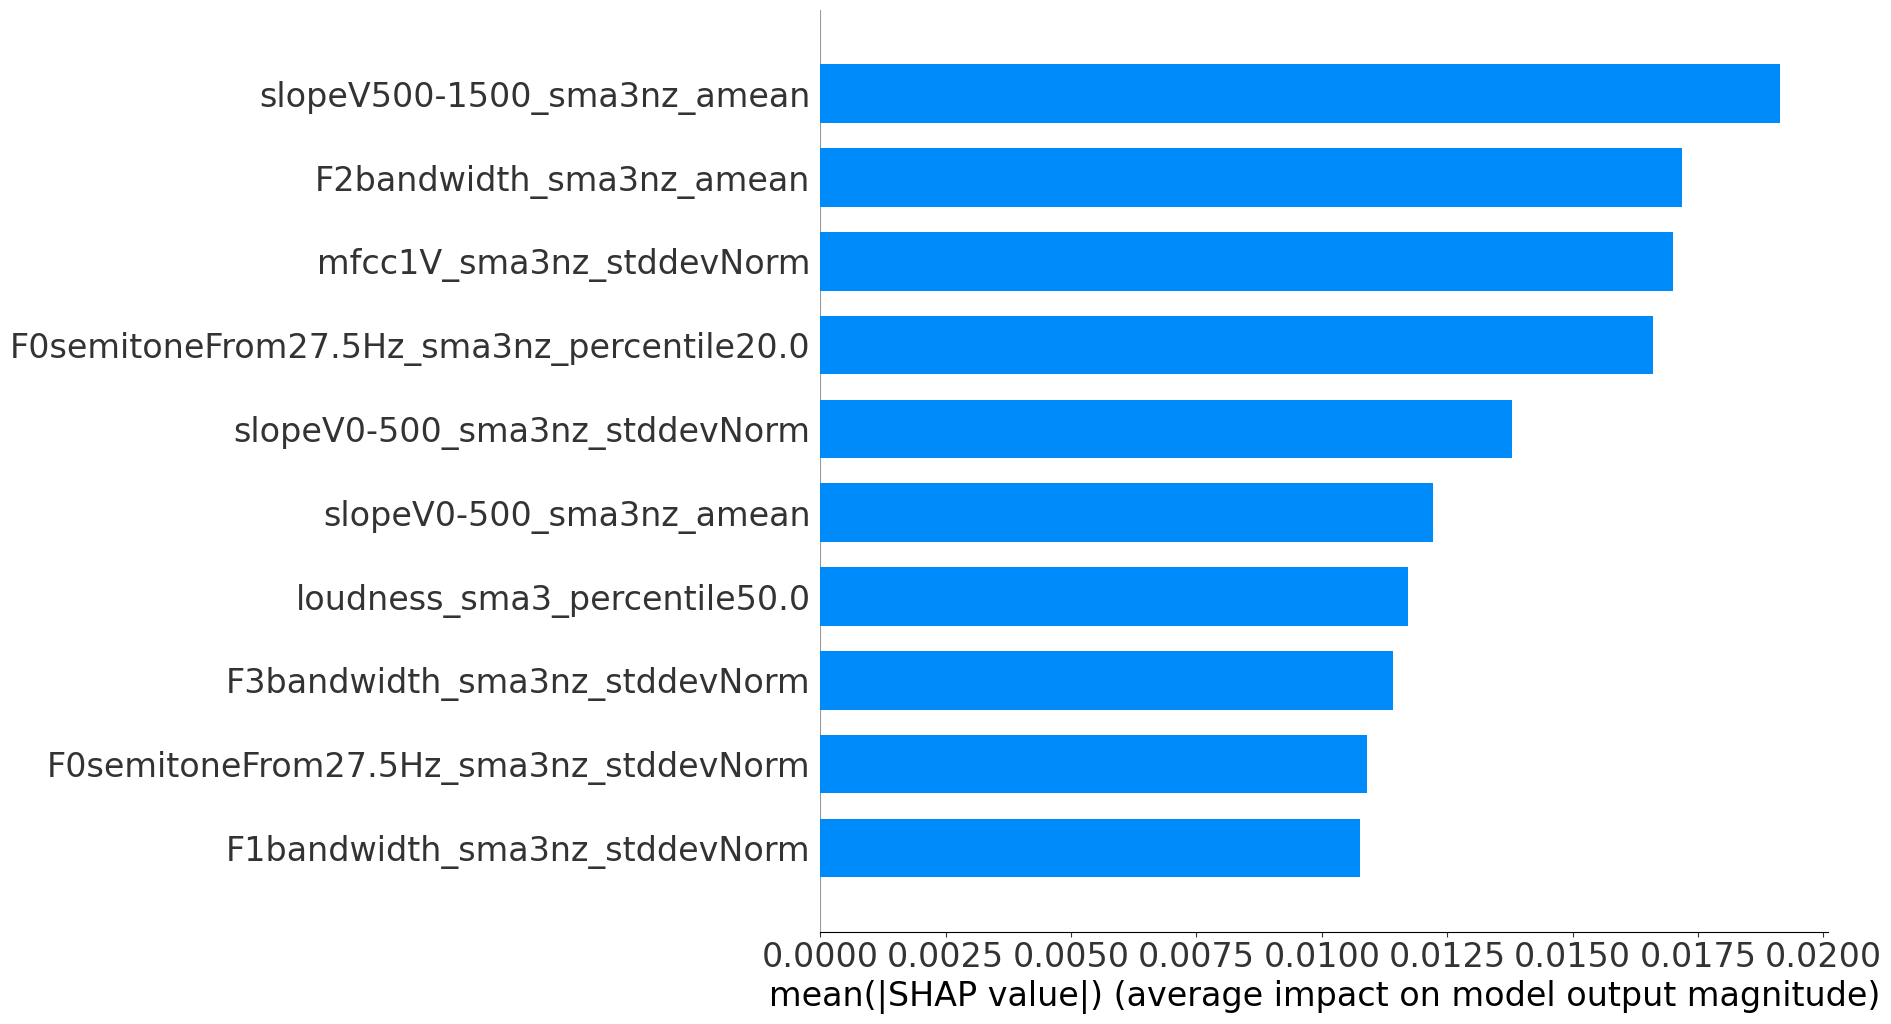

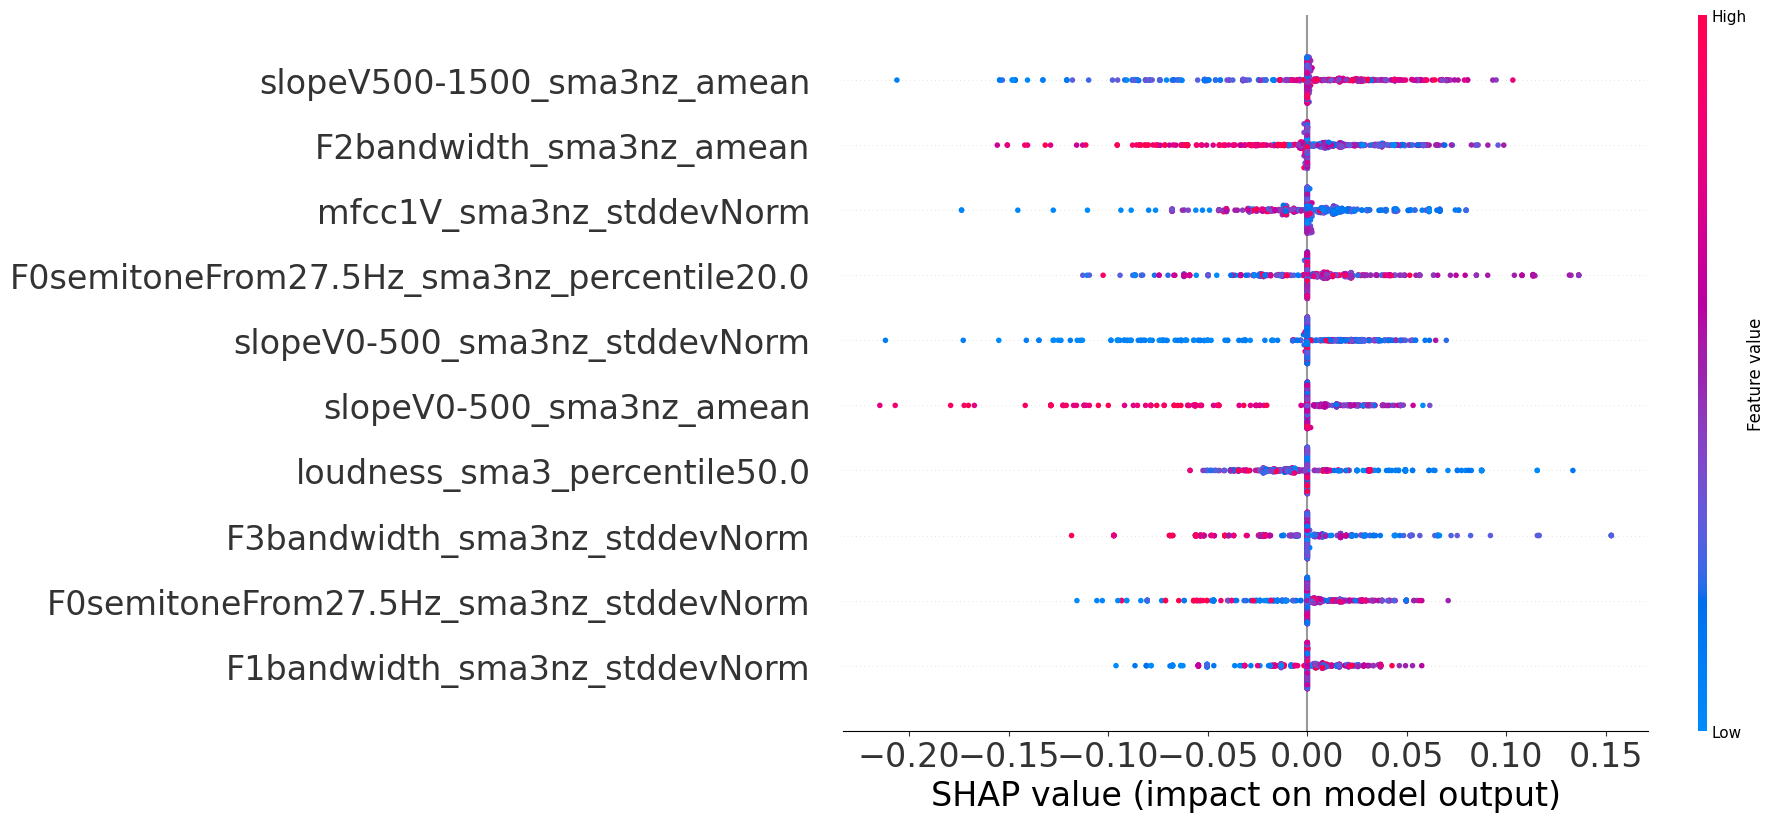

In [3]:
if __name__ == "__main__":
    main()